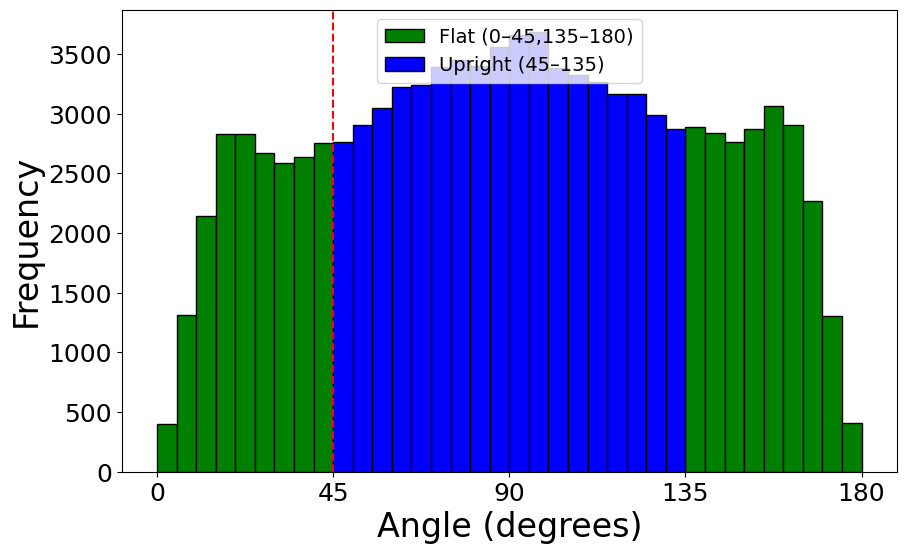

Total frames x sds analyzed: 100000
Upright count: 58491
Flat count: 41509
Upright ratio (upright/total): 0.58491
Frame 0:
  SDS 1: angle=96.15°, P2=-0.483, upright
  SDS 2: angle=126.55°, P2=0.032, upright
  SDS 3: angle=118.58°, P2=-0.157, upright
  SDS 4: angle=122.77°, P2=-0.060, upright
  SDS 5: angle=123.78°, P2=-0.036, upright
  SDS 6: angle=109.52°, P2=-0.333, upright
  SDS 7: angle=121.95°, P2=-0.080, upright
  SDS 8: angle=122.77°, P2=-0.060, upright
  SDS 9: angle=122.76°, P2=-0.061, upright
  SDS 10: angle=118.80°, P2=-0.152, upright
  SDS 11: angle=97.50°, P2=-0.474, upright
  SDS 12: angle=136.17°, P2=0.281, flat
  SDS 13: angle=96.26°, P2=-0.482, upright
  SDS 14: angle=123.82°, P2=-0.035, upright
  SDS 15: angle=101.18°, P2=-0.444, upright
  SDS 16: angle=108.97°, P2=-0.341, upright
  SDS 17: angle=106.89°, P2=-0.373, upright
  SDS 18: angle=107.69°, P2=-0.361, upright
  SDS 19: angle=95.68°, P2=-0.485, upright
  SDS 20: angle=134.23°, P2=0.230, upright
  SDS 21: angle=

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [12]:
import os
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt

# === 產生 C1 / C12 index ===
def get_C1_C12_indices(num_sds, C1_start=749, C12_start=760, atoms_per_sds=42):
    C1_list = [C1_start + i*atoms_per_sds for i in range(num_sds)]
    C12_list = [C12_start + i*atoms_per_sds for i in range(num_sds)]
    return C1_list, C12_list

# === 計算多個 sds 主軸向量 ===
def calculate_main_axis_multi(traj, C1_list, C12_list):
    num_frames = traj.n_frames
    num_sds = len(C1_list)
    main_axis_all = np.zeros((num_frames, num_sds, 3))

    for i, (c1, c12) in enumerate(zip(C1_list, C12_list)):
        pos1 = traj.xyz[:, c1, :]
        pos8 = traj.xyz[:, c12, :]
        axis = pos8 - pos1
        norm = np.linalg.norm(axis, axis=1)[:, np.newaxis]
        main_axis_all[:, i, :] = axis / norm

    return main_axis_all

# === 計算 CNT z 向量 ===
def calculate_z_vector(traj, CNT_index1, CNT_index2):
    pos1 = traj.xyz[:, CNT_index1, :]
    pos2 = traj.xyz[:, CNT_index2, :]
    z_vector = pos2 - pos1
    norm = np.linalg.norm(z_vector, axis=1)[:, np.newaxis]
    return z_vector / norm

# === 分析多個 sds 方向 (0~180° 判斷) ===
def analyze_orientation_multi(traj, C1_list, C12_list, CNT_index1, CNT_index2):
    main_axis = calculate_main_axis_multi(traj, C1_list, C12_list)  # (frames, sds, 3)
    z_vector = calculate_z_vector(traj, CNT_index1, CNT_index2)    # (frames, 3)
    z_vector_expanded = z_vector[:, np.newaxis, :]                  # (frames, 1, 3)

    # dot product → cosθ，範圍 -1~1
    cos_theta = np.sum(main_axis * z_vector_expanded, axis=2)

    # 角度範圍 0–180°
    angles_deg = np.degrees(np.arccos(cos_theta))

    # P2 order parameter
    p2 = 0.5 * (3 * cos_theta**2 - 1)

    # 判斷直立/躺平
    orientation = np.where((angles_deg >= 45) & (angles_deg <= 135), 'upright', 'flat')

    return p2, angles_deg, orientation

# === 載入軌跡 ===
trj_file1 = "/work/jane/nano/NPT/explicit/2mrg_sds200/run_00/mrg_sds_200_i.dcd"
pdb_file1 = "/home/jane/nano/add_ion/NPT/explicit/2mrg_sds200/mrg_sds_200_i.pdb"
traj_CF_straight_o_00 = md.load(trj_file1, top=pdb_file1, stride=20)

# === 設定 sds 和 CNT ===
num_sds = 200
C1_list, C12_list = get_C1_C12_indices(num_sds)
CNT_index1 = 51    # 根據你的系統調整
CNT_index2 = 511   # 根據你的系統調整

# === 執行分析 ===
p2_values, angles, orientation_labels = analyze_orientation_multi(
    traj_CF_straight_o_00, C1_list, C12_list, CNT_index1, CNT_index2
)

# === 計算各幀平均 P2 和直立比例 ===
avg_p2 = np.mean(p2_values, axis=1)
upright_ratio = np.mean(orientation_labels == 'upright', axis=1)

# =====將 angles 展平成一維=======
angles_flat = angles.flatten()

# === Histogram (0–180°) ===
bins = 36  # 每 bin = 5 度
counts, bin_edges = np.histogram(angles_flat, bins=bins, range=(0,180))

# 計算每個 bin 中心
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bar_width = bin_edges[1] - bin_edges[0]

# 分組 mask
upright_mask = (bin_centers >= 45) & (bin_centers <= 135)
flat_mask = ~upright_mask

plt.figure(figsize=(10,6))

# 畫 histogram：分成直立 / 躺平
plt.bar(bin_centers[flat_mask], counts[flat_mask], width=bar_width, 
        color='green', edgecolor='black', label='Flat (0–45,135–180)')
plt.bar(bin_centers[upright_mask], counts[upright_mask], width=bar_width, 
        color='blue', edgecolor='black', label='Upright (45–135)')

# 閾值線
plt.axvline(45, color='red', linestyle='--')
#plt.axvline(135, color='red', linestyle='--', label='Thresholds (45°,135°)')
plt.tick_params(axis='both', which='major', labelsize=18)

# 標籤與標題
plt.xlabel("Angle (degrees)", fontsize=24)
plt.ylabel("Frequency", fontsize=24)
#plt.title("Angle distribution (0–180°), 5°/bin ", fontsize=22)
plt.legend(fontsize=14, loc='upper center')
plt.xticks([0, 45, 90, 135, 180])



plt.show()

# === 統計直立 / 平躺數量 ===
upright_count = np.sum(orientation_labels == 'upright')
flat_count = np.sum(orientation_labels == 'flat')

print(f"Total frames x sds analyzed: {orientation_labels.size}")
print(f"Upright count: {upright_count}")
print(f"Flat count: {flat_count}")
print(f"Upright ratio (upright/total): {upright_count/orientation_labels.size}")

# === 範例輸出前 500 幀結果 (每個 sds) ===
for i in range(500):
    print(f"Frame {i}:")
    for j in range(num_sds):
        print(f"  SDS {j+1}: angle={angles[i,j]:.2f}°, P2={p2_values[i,j]:.3f}, {orientation_labels[i,j]}")

In [11]:
import pandas as pd

# ===== 整理成 long-format 表格 =====
num_frames = traj_CF_straight_o_00.n_frames

frame_list = []
sds_list = []
angle_list = []
p2_list = []
orientation_list = []

for i in range(num_frames):
    for j in range(num_sds):
        frame_list.append(i)
        sds_list.append(j+1)
        angle_list.append(angles[i, j])
        p2_list.append(p2_values[i, j])
        orientation_list.append(orientation_labels[i, j])

df = pd.DataFrame({
    "Frame": frame_list,
    "SDS_ID": sds_list,
    "Angle_deg": angle_list,
    "P2": p2_list,
    "Orientation": orientation_list
})

# ===== 存成 CSV =====
output_file = "200sds.csv"
df.to_csv(output_file, index=False)

print(f"Data saved to {output_file}")

Data saved to 100sds.csv
